In [1]:
import subprocess
import sys
subprocess.run([sys.executable, "-m", "pip", "install",
    "pandas", "numpy", "matplotlib", "seaborn",
    "scikit-learn", "xgboost", "imbalanced-learn", "joblib"])

CompletedProcess(args=['c:\\Users\\priti\\OneDrive\\Desktop\\customer-churn-predictor\\venv\\Scripts\\python.exe', '-m', 'pip', 'install', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn', 'xgboost', 'imbalanced-learn', 'joblib'], returncode=0)

In [6]:
df = pd.read_csv('../data/cleaned_churn.csv')

# Fix NaN values
df = df.dropna()
df = df.fillna(0)

X = df.drop('Churn', axis=1)
y = df['Churn'].astype(int)

print("X shape:", X.shape)
print("Any NaN in X?", X.isnull().sum().sum())
print("Churn distribution:\n", y.value_counts())

X shape: (7032, 30)
Any NaN in X? 0
Churn distribution:
 Churn
0    5163
1    1869
Name: count, dtype: int64


In [7]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)
print("After SMOTE:", X_res.shape)
print(pd.Series(y_res).value_counts())

After SMOTE: (10326, 30)
Churn
0    5163
1    5163
Name: count, dtype: int64


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

joblib.dump(scaler, '../models/scaler.pkl')
print("✅ Data split and scaled!")

✅ Data split and scaled!


In [9]:
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)
model.fit(X_train, y_train)
print("✅ Model trained!")

✅ Model trained!


In [10]:
y_pred = model.predict(X_test)
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))
print("AUC-ROC Score:", round(roc_auc_score(y_test, y_pred), 4))

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.84      0.82      0.83      1037
           1       0.83      0.85      0.84      1029

    accuracy                           0.84      2066
   macro avg       0.84      0.84      0.84      2066
weighted avg       0.84      0.84      0.84      2066

AUC-ROC Score: 0.836


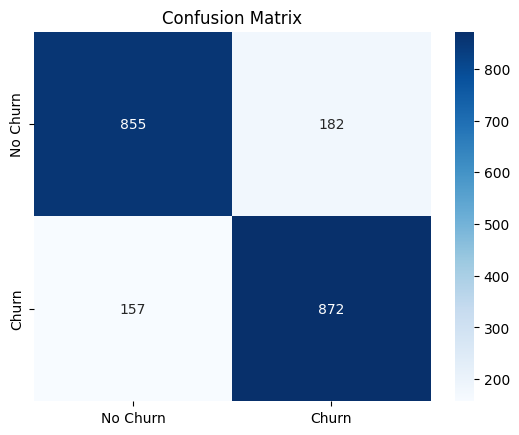

In [11]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'])
plt.title('Confusion Matrix')
plt.savefig('../data/confusion_matrix.png')
plt.show()

In [12]:
joblib.dump(model, '../models/xgb_model.pkl')
joblib.dump(list(df.drop('Churn', axis=1).columns), '../models/columns.pkl')
print("✅ Model saved!")

✅ Model saved!
